# Advanced URL Maliciousness Classifier

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import torch
warnings.filterwarnings('ignore')

from url_classifier import URLClassifier, URLFeatureExtractor
from url_classifier import plot_training_history, plot_confusion_matrix, plot_roc_curve

print("All imports successful!")

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

All imports successful!


## 2. Load and Explore Dataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load your dataset
DATASET_PATH = 'data/data-new.csv'  # Change this to your dataset path

df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (42750, 2)

Column names: ['text', 'label']

First few rows:


,text,label
0,br-icloud.com.br,1
1,http://www.garage-pirenne.be/index.php?option=...,1
2,http://adventure-nicaragua.net/index.php?optio...,1
3,http://www.pashminaonline.com/pure-pashminas,1
4,http://www.ikenmijnkunst.nl/index.php/expositi...,1


Dataset Statistics
Total URLs: 42750
Benign URLs: 29495 (68.99%)
Malicious URLs: 13255 (31.01%)


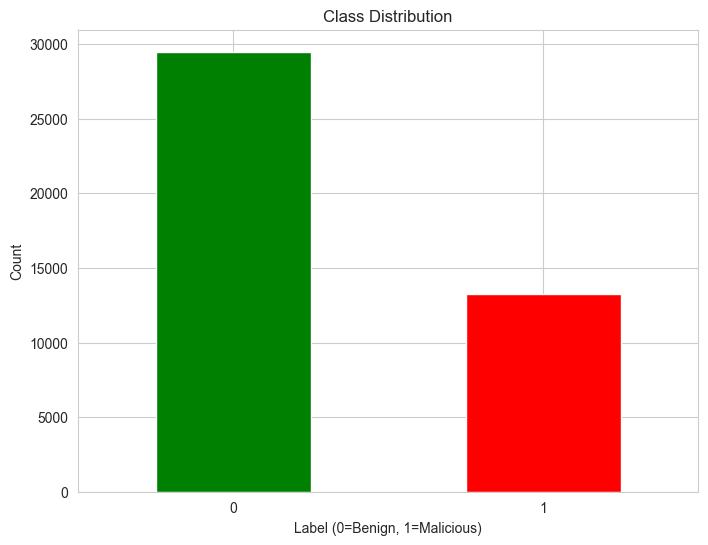

In [3]:
# Dataset statistics
print("Dataset Statistics")
print("="*50)
print(f"Total URLs: {len(df)}")
print(f"Benign URLs: {sum(df['label'] == 0)} ({sum(df['label'] == 0)/len(df)*100:.2f}%)")
print(f"Malicious URLs: {sum(df['label'] == 1)} ({sum(df['label'] == 1)/len(df)*100:.2f}%)")

# Visualize class distribution
plt.figure(figsize=(8, 6))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution')
plt.xlabel('Label (0=Benign, 1=Malicious)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 3. Feature Analysis

In [4]:
# Extract features for analysis
feature_extractor = URLFeatureExtractor()

# Sample URLs for feature analysis
sample_size = min(1000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

features_list = []
for url in sample_df['text']:
    features_list.append(feature_extractor.extract_numerical_features(url))

features_df = pd.DataFrame(features_list)
features_df['label'] = sample_df['label'].values

print("Extracted Features:")
features_df.head()

Extracted Features:


,url_length,domain_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_questionmarks,num_equals,num_ats,...,num_params,has_ip,has_suspicious_tld,entropy,digit_ratio,special_char_ratio,obfuscation_score,subdomain_count,path_depth,label
0,55,0,55,2,1,2,2,0,0,0,...,0,0,0,4.367749,0.000000,0.163636,0,0,3,0
1,104,30,67,4,7,0,4,0,0,0,...,0,0,0,4.423293,0.019231,0.153846,0,2,2,1
2,58,0,58,2,4,0,3,0,0,0,...,0,0,0,4.281672,0.103448,0.155172,0,0,4,0
3,30,0,30,1,0,0,3,0,0,0,...,0,0,0,4.215061,0.000000,0.133333,0,0,4,0
4,9,0,9,1,0,0,1,0,0,0,...,0,0,0,3.169925,0.000000,0.222222,0,0,1,0


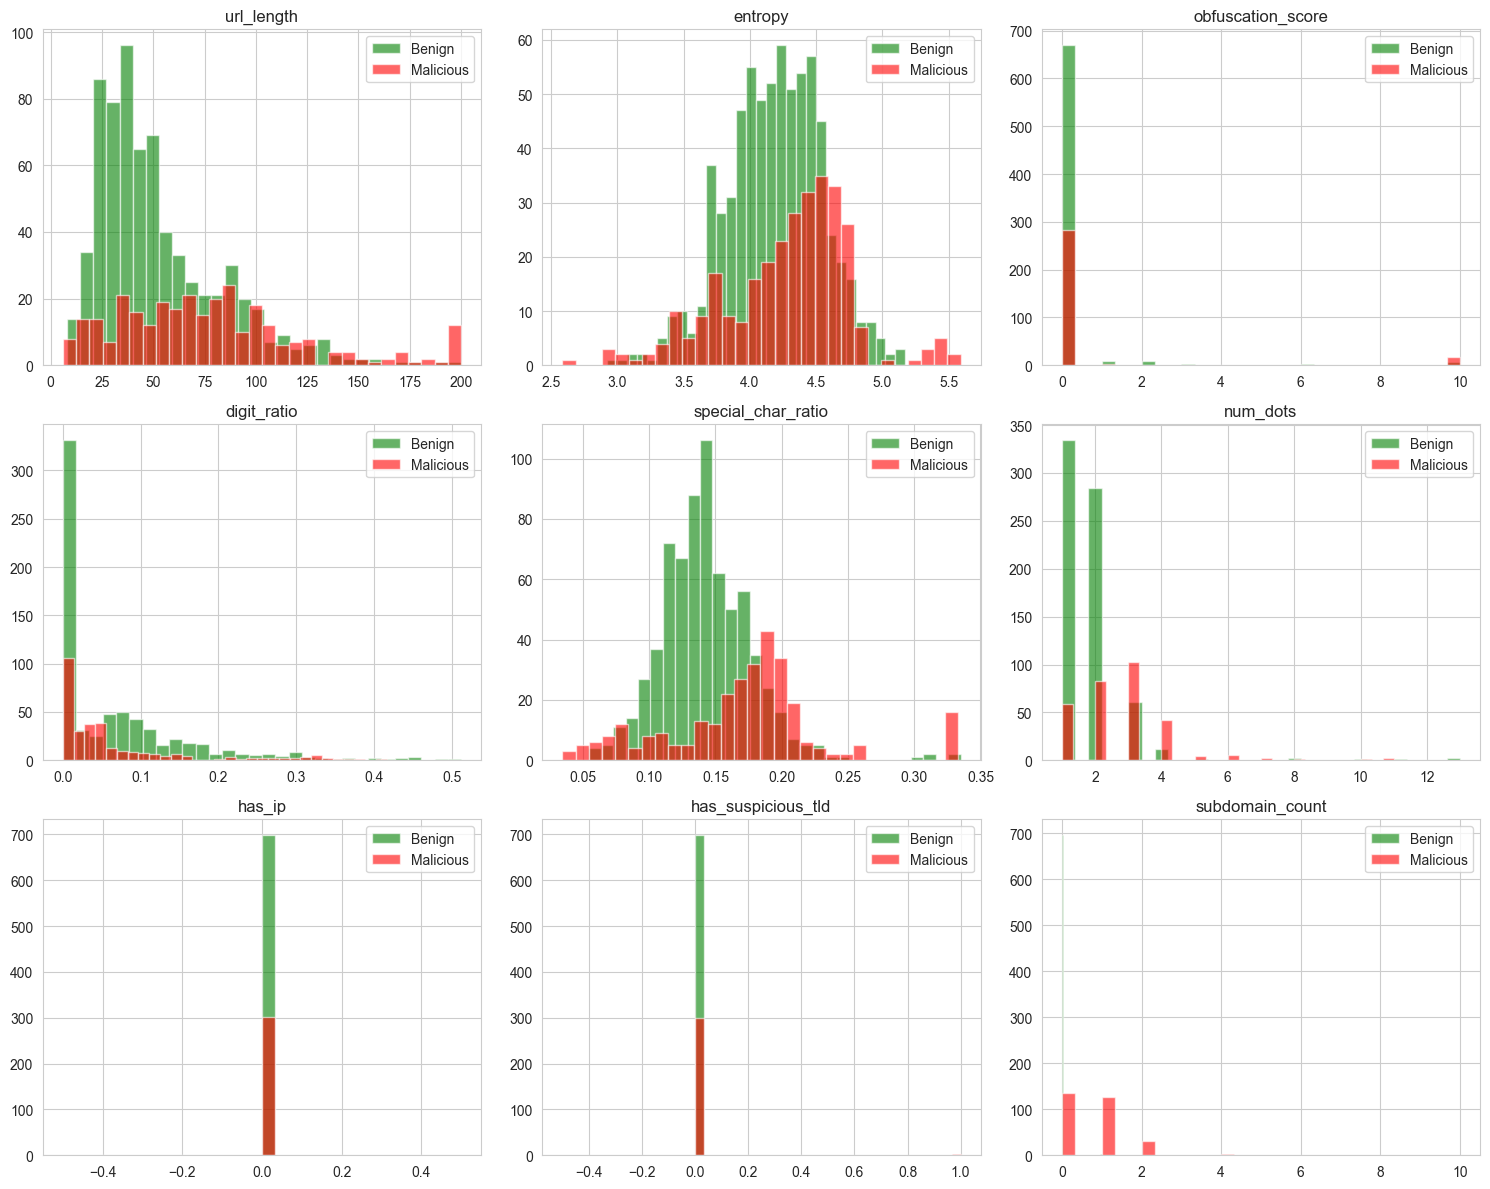

In [5]:
# Compare features between benign and malicious URLs
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

important_features = [
    'url_length', 'entropy', 'obfuscation_score', 
    'digit_ratio', 'special_char_ratio', 'num_dots',
    'has_ip', 'has_suspicious_tld', 'subdomain_count'
]

for idx, feature in enumerate(important_features):
    ax = axes[idx]
    
    benign = features_df[features_df['label'] == 0][feature]
    malicious = features_df[features_df['label'] == 1][feature]
    
    ax.hist(benign, alpha=0.6, label='Benign', bins=30, color='green')
    ax.hist(malicious, alpha=0.6, label='Malicious', bins=30, color='red')
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()

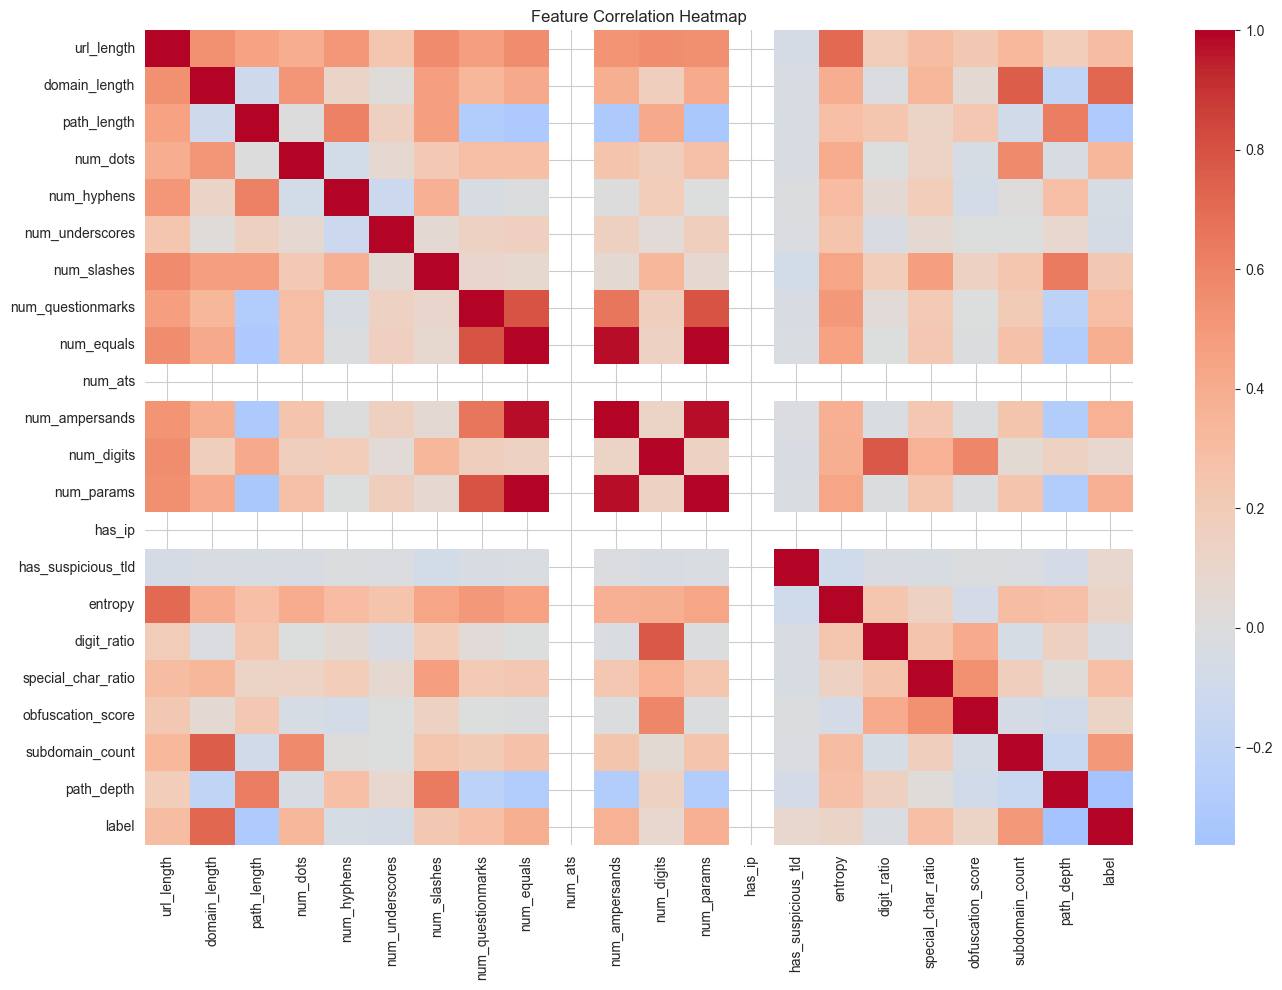

In [6]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = features_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Prepare Data for Training

In [7]:
# Extract URLs and labels
urls = df['text'].values
labels = df['label'].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    urls, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nTraining set distribution:")
print(f"  Benign: {sum(y_train == 0)}")
print(f"  Malicious: {sum(y_train == 1)}")
print(f"\nTest set distribution:")
print(f"  Benign: {sum(y_test == 0)}")
print(f"  Malicious: {sum(y_test == 1)}")

Training samples: 34200
Testing samples: 8550

Training set distribution:
  Benign: 23596
  Malicious: 10604

Test set distribution:
  Benign: 5899
  Malicious: 2651


## 5. Build and Train Model

In [8]:
# Initialize classifier
classifier = URLClassifier(
    max_chars=200,
    max_words=50,
    char_embed_dim=32,
    word_embed_dim=64
)

# Prepare tokenizers
print("Preparing tokenizers...")
classifier._tokenize_characters(X_train)
classifier._tokenize_words(X_train)

print(f"\nCharacter vocabulary size: {len(classifier.char_tokenizer.word_index)}")
print(f"Word vocabulary size: {len(classifier.word_tokenizer.word_index)}")

# Build model
print("\nBuilding model...")
model = classifier.build_model()
model.summary()

Preparing tokenizers...

Character vocabulary size: 124
Word vocabulary size: 49152

Building model...



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)    │ (None, 21)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ char_input (InputLayer)       │ (None, 200)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ word_input (InputLayer)       │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 32)                │             704 │ feature_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 200, 32)           │           4,000 │ char_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 200)               │               0 │ char_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 50, 64)            │       3,145,792 │ word_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_1 (NotEqual)        │ (None, 50)                │               0 │ word_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 32)                │             128 │ dense_4[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 200, 128)          │          49,664 │ embedding[0][0],           │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 50, 128)           │          49,920 │ embedding_1[0][0],         │
│ (Bidirectional)               │                           │                 │ not_equal_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 32)                │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_layer               │ (None, 128)               │           8,321 │ bidirectional[0][0]        │
│ (AttentionLayer)              │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_layer_1             │ (None, 128)               │           8,321 │ bidirectional_1[0][0]      │
│ (AttentionLayer)              │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 16)                │             52

 Total params: 3,313,523 (12.64 MB)

 Trainable params: 3,313,043 (12.64 MB)

 Non-trainable params: 480 (1.88 KB)

In [9]:
# Train model
print("Training model...")
print("This may take several minutes...\n")

history = classifier.train(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,  # Adjust as needed
    batch_size=32
)

print("\nTraining complete!")

Training model...
This may take several minutes...

Epoch 1/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9026 - auc: 0.9510 - loss: 0.2280 - precision: 0.8451 - recall: 0.8654
Epoch 1: val_auc improved from None to 0.99899, saving model to best_url_model.keras

Epoch 1: finished saving model to best_url_model.keras
855/855 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.9630 - auc: 0.9921 - loss: 0.0987 - precision: 0.9420 - recall: 0.9377 - val_accuracy: 0.9969 - val_auc: 0.9990 - val_loss: 0.0122 - val_precision: 0.9972 - val_recall: 0.9931 - learning_rate: 0.0010
Epoch 2/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9967 - auc: 0.9992 - loss: 0.0132 - precision: 0.9955 - recall: 0.9938
Epoch 2: val_auc improved from 0.99899 to 0.99930, saving model to best_url_model.keras

Epoch 2: finished saving model to best_url_model.keras
855/855 ━━━━━━━━━━━━━━━━━━━━ 77s 90ms/step - accuracy: 0.9971 - auc: 0.9992 - loss: 0.0117 - precision: 0.9955 - recall: 0.9950 - va

## 6. Visualize Training Results

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/training_history.png'

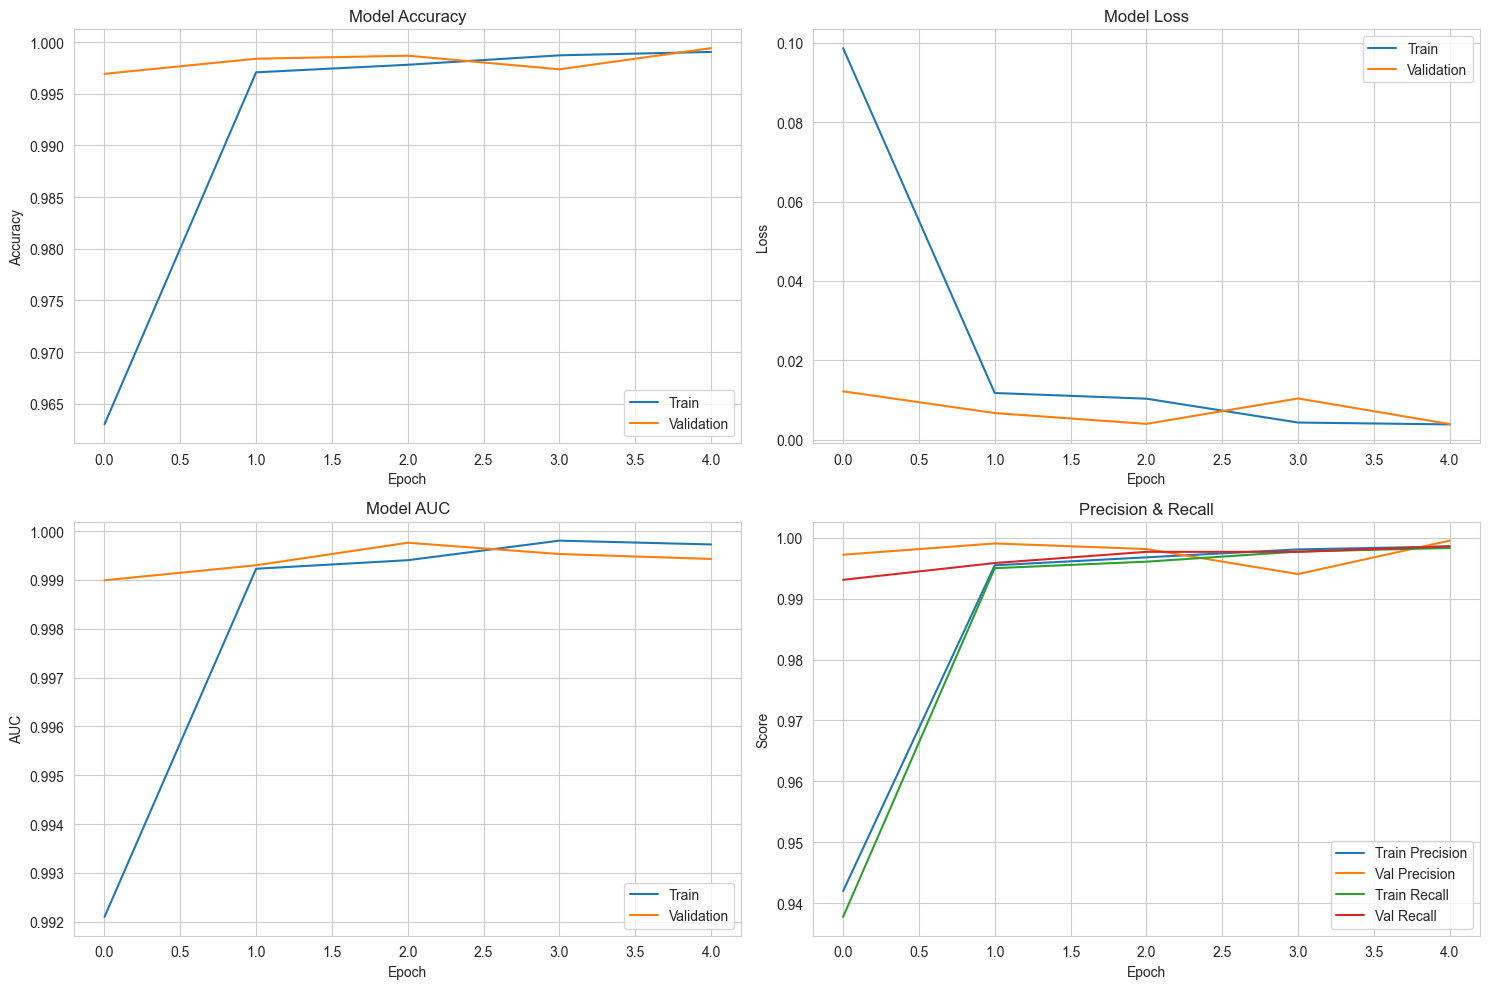

In [10]:
# Plot training history
plot_training_history(history)

## 7. Evaluate Model

In [11]:
# Evaluate on test set
results, y_pred_proba, y_pred = classifier.evaluate(X_test, y_test)

268/268 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step

MODEL EVALUATION RESULTS
Loss: 0.0118
Accuracy: 0.9985
AUC: 0.9984
Precision: 0.9989
Recall: 0.9962

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5899
   Malicious       1.00      1.00      1.00      2651

    accuracy                           1.00      8550
   macro avg       1.00      1.00      1.00      8550
weighted avg       1.00      1.00      1.00      8550



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/confusion_matrix.png'

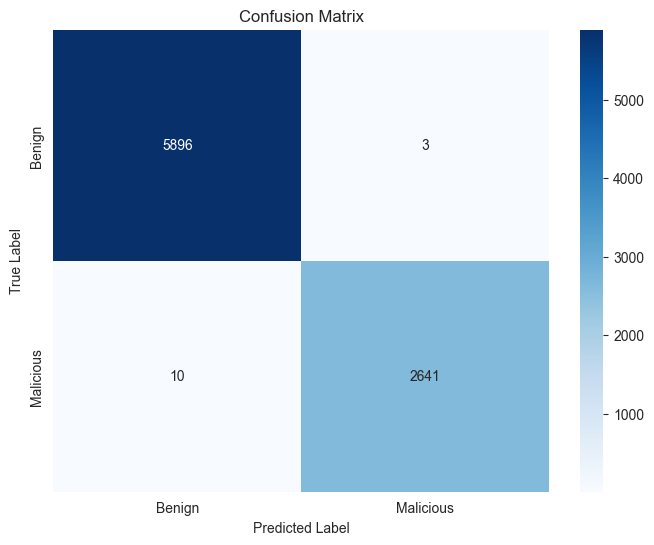

In [12]:
# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred)

In [ ]:
# Plot ROC curve
plot_roc_curve(y_test, y_pred_proba)

## 8. Analyze Predictions

In [ ]:
# Analyze misclassified URLs
misclassified_indices = np.where(y_pred.flatten() != y_test)[0]

print(f"Total misclassified: {len(misclassified_indices)}")
print(f"\nSample of misclassified URLs:\n")

for idx in misclassified_indices[:10]:
    url = X_test[idx]
    true_label = "Malicious" if y_test[idx] == 1 else "Benign"
    pred_label = "Malicious" if y_pred[idx] == 1 else "Benign"
    confidence = y_pred_proba[idx][0]
    
    print(f"URL: {url}")
    print(f"True: {true_label}, Predicted: {pred_label}, Confidence: {confidence:.4f}")
    print("-" * 80)

In [ ]:
# Prediction confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Benign predictions
benign_conf = y_pred_proba[y_test == 0]
axes[0].hist(benign_conf, bins=50, alpha=0.7, color='green')
axes[0].set_title('Confidence Distribution - True Benign URLs')
axes[0].set_xlabel('Predicted Probability (Malicious)')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='red', linestyle='--', label='Decision Threshold')
axes[0].legend()

# Malicious predictions
malicious_conf = y_pred_proba[y_test == 1]
axes[1].hist(malicious_conf, bins=50, alpha=0.7, color='red')
axes[1].set_title('Confidence Distribution - True Malicious URLs')
axes[1].set_xlabel('Predicted Probability (Malicious)')
axes[1].set_ylabel('Count')
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Test on Custom URLs

In [ ]:
# Test custom URLs
test_urls = [
    "https://www.google.com",
    "http://malicious-phishing-site.xyz/login.php?user=admin",
    "https://github.com/tensorflow/tensorflow",
    "http://192.168.1.1/admin/config.php",
    "https://www.amazon.com/product/dp/B08N5WRWNW",
    "http://free-iphone-winner.tk/claim?id=12345",
]

predictions = classifier.predict(test_urls)

print("Custom URL Predictions:")
print("=" * 80)

for url, pred in zip(test_urls, predictions):
    label = "MALICIOUS ⚠️" if pred[0] > 0.5 else "BENIGN ✓"
    confidence = pred[0] if pred[0] > 0.5 else 1 - pred[0]
    
    print(f"\nURL: {url}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Score: {pred[0]:.4f}")
    print("-" * 80)

## 10. Save Model

In [ ]:
# Save the trained model
model.save('url_classifier_model.keras')
print("Model saved as 'url_classifier_model.keras'")

# Save tokenizers (for later use)
import pickle

with open('char_tokenizer.pkl', 'wb') as f:
    pickle.dump(classifier.char_tokenizer, f)

with open('word_tokenizer.pkl', 'wb') as f:
    pickle.dump(classifier.word_tokenizer, f)

print("Tokenizers saved!")

## 11. Feature Importance Analysis

In [ ]:
# Extract feature importance by comparing benign vs malicious
benign_features = features_df[features_df['label'] == 0].drop('label', axis=1)
malicious_features = features_df[features_df['label'] == 1].drop('label', axis=1)

# Calculate mean difference
feature_importance = abs(malicious_features.mean() - benign_features.mean()).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Mean Absolute Difference)')
plt.xlabel('Mean Absolute Difference')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

## 12. Summary Statistics

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

# Calculate additional metrics
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nTest Set Size: {len(y_test)}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Precision: {results[3]:.4f}")
print(f"Test Recall: {results[4]:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"\nMisclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)")
print("="*60)